In [2]:
!pip install statsmodels


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [4]:
df = pd.read_csv("data/processed/monthly_housing_clean.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")
y = df["hpi"].dropna()

# rolling mean 與 rolling standard deviation
y_rolling_mean_12 = y.rolling(window=12).mean()
y_rolling_std_12 = y.rolling(window=12).std()

## Stationary inspection

### 12 month rolling mean

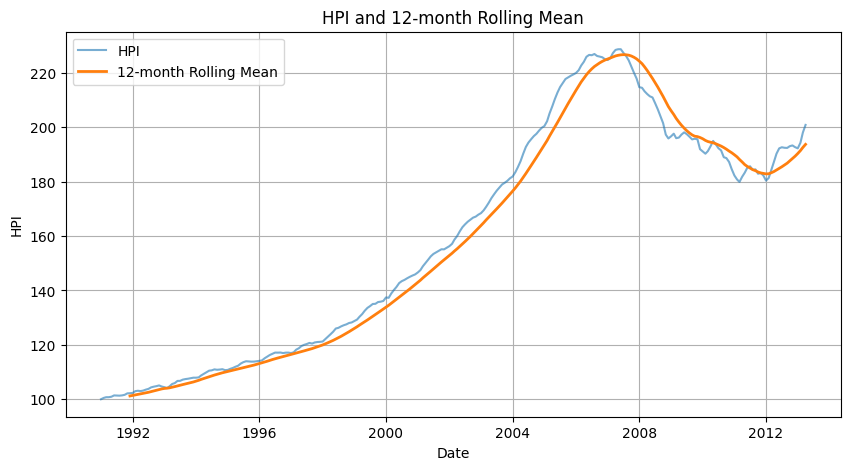

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(y.index, y, label="HPI", alpha=0.6)
plt.plot(y_rolling_mean_12.index, y_rolling_mean_12,
         label="12-month Rolling Mean", linewidth=2)

plt.title("HPI and 12-month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("HPI")
plt.legend()
plt.grid(True)

plt.show()

### 12 month rolling std

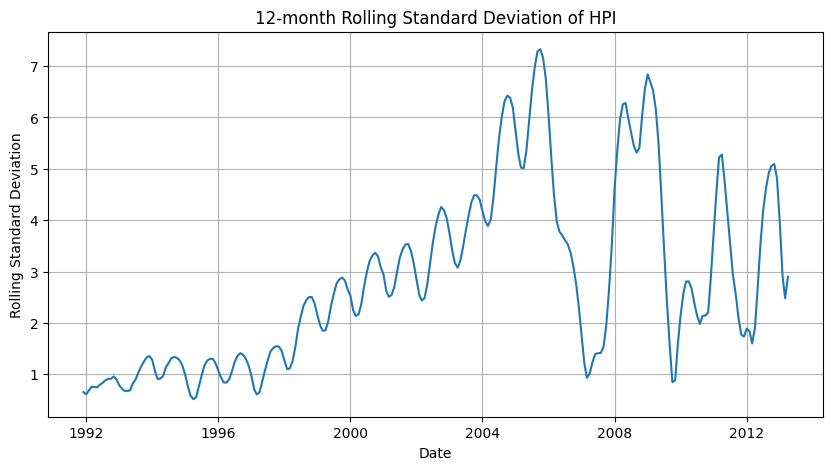

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(y_rolling_std_12.index, y_rolling_std_12)

plt.title("12-month Rolling Standard Deviation of HPI")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(True)

plt.show()

### ACF plot

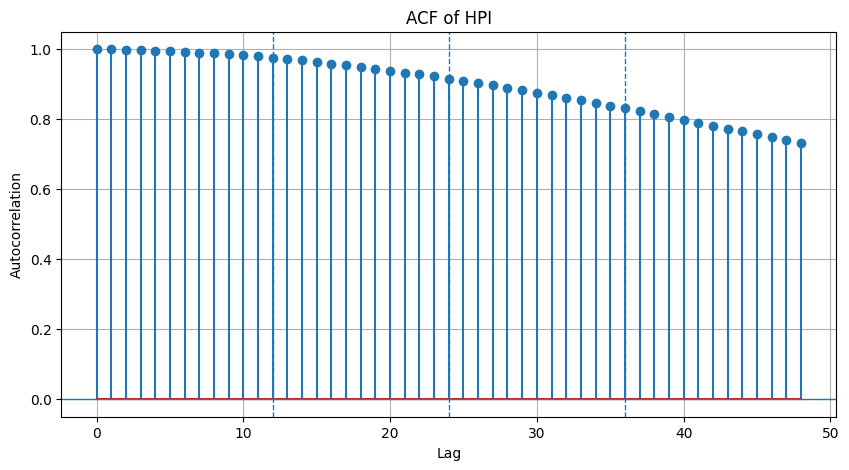

In [7]:
max_lag = 48

acf_values = [y.autocorr(lag=lag) for lag in range(max_lag + 1)]

plt.figure(figsize=(10, 5))

plt.stem(range(max_lag + 1), acf_values)

for lag in [12, 24, 36]:
    plt.axvline(x=lag, linestyle="--", linewidth=1)

plt.axhline(y=0, linewidth=1)

plt.title("ACF of HPI")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)

plt.show()

### monthly seasonal plot

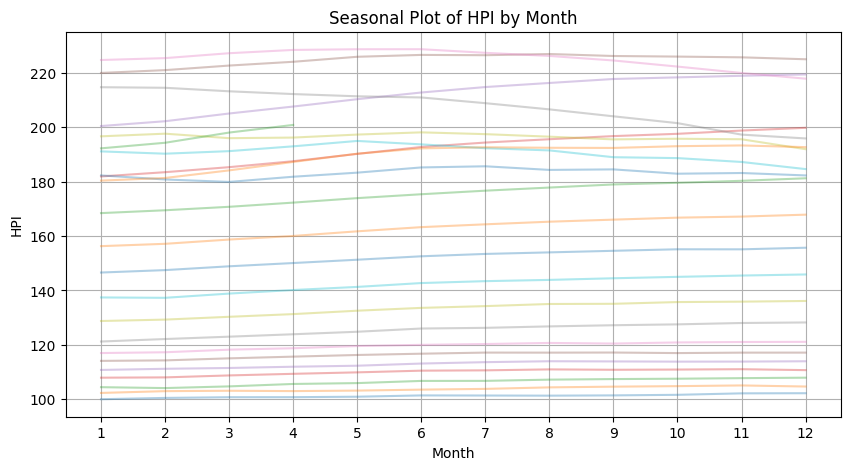

In [8]:
season_df = y.to_frame(name="hpi")
season_df["year"] = season_df.index.year
season_df["month"] = season_df.index.month

plt.figure(figsize=(10, 5))

for year, group in season_df.groupby("year"):
    plt.plot(group["month"], group["hpi"], alpha=0.35)

plt.title("Seasonal Plot of HPI by Month")
plt.xlabel("Month")
plt.ylabel("HPI")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [9]:
# ADF test
for reg in ["c", "ct"]:
    result = adfuller(y, regression=reg, autolag="AIC")
    print(f"\nADF test regression = {reg}")
    print("----------------------")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Used Lag: {result[2]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value:.4f}")


ADF test regression = c
----------------------
ADF Statistic: -1.1976
p-value: 0.6746
Used Lag: 16
Critical Values:
1%: -3.4567
5%: -2.8731
10%: -2.5729

ADF test regression = ct
----------------------
ADF Statistic: -2.8435
p-value: 0.1814
Used Lag: 16
Critical Values:
1%: -3.9953
5%: -3.4281
10%: -3.1374
